In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from datetime import datetime

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

## Load Raw Data

In [3]:
# Load the raw complaints data
df = pd.read_csv('C:\\Users\\aswan\\My ML projects\\GenAi\\data\\raw\\complaints.csv', low_memory=False)
print(f"Total rows: {len(df)}")
print(f"Total columns: {len(df.columns)}")
df.head()

Total rows: 12389904
Total columns: 18


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2020-07-06,"Credit reporting, credit repair services, or other personal consumer reports",Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Experian Information Solutions Inc.,FL,346XX,NaN,Other,Web,2020-07-06,Closed with explanation,Yes,NaN,3730948
1,2025-11-25,Credit reporting or other personal consumer reports,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,"EQUIFAX, INC.",GA,30311,NaN,NaN,Web,2025-11-25,In progress,Yes,NaN,17487731
2,2025-10-14,Credit reporting or other personal consumer reports,Credit reporting,Incorrect information on your report,Information is missing that should be on the report,NaN,NaN,"EQUIFAX, INC.",TX,75062,NaN,NaN,Web,2025-10-14,Closed with non-monetary relief,Yes,NaN,16558024
3,2025-10-26,Credit reporting or other personal consumer reports,Credit reporting,Incorrect information on your report,Information belongs to someone else,Be sure that disputed accounts are taken down promptly in accordance with the law.,Company has responded to the consumer and the CFPB and chooses not to provide a public response,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",CA,93619,NaN,Consent provided,Web,2025-10-26,Closed with non-monetary relief,Yes,NaN,16826857
4,2025-10-10,Credit reporting or other personal consumer reports,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,"EQUIFAX, INC.",GA,30341,NaN,Consent not provided,Web,2025-10-10,Closed with non-monetary relief,Yes,NaN,16507707


In [4]:
# Check column names
print("Available columns:")
for col in df.columns:
    print(f"  - {col}")

Available columns:
  - Date received
  - Product
  - Sub-product
  - Issue
  - Sub-issue
  - Consumer complaint narrative
  - Company public response
  - Company
  - State
  - ZIP code
  - Tags
  - Consumer consent provided?
  - Submitted via
  - Date sent to company
  - Company response to consumer
  - Timely response?
  - Consumer disputed?
  - Complaint ID


In [5]:
# Check for the complaint narrative column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12389904 entries, 0 to 12389903
Data columns (total 18 columns):
 #   Column                        Dtype 
---  ------                        ----- 
 0   Date received                 object
 1   Product                       object
 2   Sub-product                   object
 3   Issue                         object
 4   Sub-issue                     object
 5   Consumer complaint narrative  object
 6   Company public response       object
 7   Company                       object
 8   State                         object
 9   ZIP code                      object
 10  Tags                          object
 11  Consumer consent provided?    object
 12  Submitted via                 object
 13  Date sent to company          object
 14  Company response to consumer  object
 15  Timely response?              object
 16  Consumer disputed?            object
 17  Complaint ID                  int64 
dtypes: int64(1), object(17)
memory usage: 1.

## Filter and Sample Data

In [6]:
# Filter rows where complaint narrative is not null
df_filtered = df[df['Consumer complaint narrative'].notna()].copy()
print(f"Rows with complaint narrative: {len(df_filtered)}")

# Sample between 10k-30k rows (using 15k as middle ground)
sample_size = min(15000, len(df_filtered))
df_sample = df_filtered.sample(n=sample_size, random_state=42)
print(f"Sampled rows: {len(df_sample)}")

Rows with complaint narrative: 3564725
Sampled rows: 15000


In [7]:
# Keep only required columns and rename for consistency
df_clean = df_sample[['Consumer complaint narrative', 'Product', 'Issue', 'Date received']].copy()
df_clean.columns = ['complaint_text', 'product', 'issue', 'date']

print(f"Final shape: {df_clean.shape}")
df_clean.head()

Final shape: (15000, 4)


,complaint_text,product,issue,date
2145278,I asked to put a security free on my account a few months. I am not sure if the credit bureaus d...,"Credit reporting, credit repair services, or other personal consumer reports",Incorrect information on your report,2021-03-19
3893728,"On XX/XX/XXXX at XXXX XXXX, I contacted XXXX XXXX XXXX. I spoke to XXXX. XXXX identification num...",Student loan,Dealing with your lender or servicer,2018-04-21
11156304,This CFPB complaint has been filed to request pursuant to FCRA 605B ( 15 U.S.C. 1681c-2 ) that y...,Credit reporting or other personal consumer reports,Improper use of your report,2025-08-19
491315,Lakeview Loan Servicing LLC continues to contact me for payment while I am on a forbearance. The...,Mortgage,Struggling to pay mortgage,2021-04-20
2167447,On XXXX XXXX I received my dispute results from Experian. Experian stated during their reinvesti...,"Credit reporting, credit repair services, or other personal consumer reports",Problem with a credit reporting company's investigation into an existing problem,2022-01-07


## Data Quality Check

In [8]:
# Check for missing values
print("Missing values:")
print(df_clean.isnull().sum())
print(f"\nMissing percentage:")
print(df_clean.isnull().sum() / len(df_clean) * 100)

Missing values:
complaint_text    0
product           0
issue             0
date              0
dtype: int64

Missing percentage:
complaint_text    0.0
product           0.0
issue             0.0
date              0.0
dtype: float64


Average complaint length: 1009 characters
Min length: 17
Max length: 32368


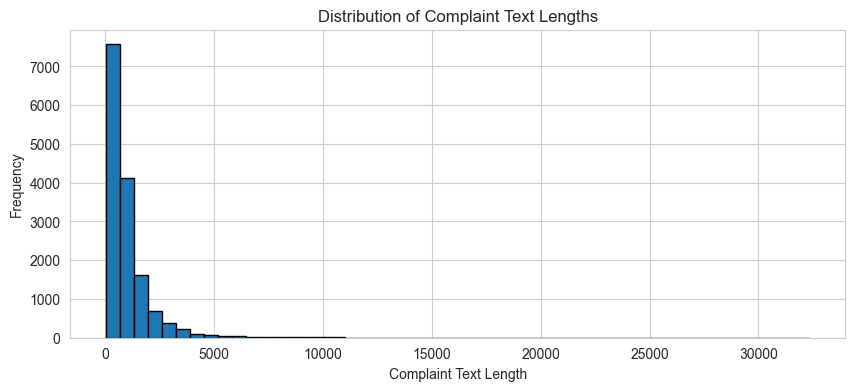

In [9]:
# Check complaint text lengths
df_clean['text_length'] = df_clean['complaint_text'].str.len()
print(f"Average complaint length: {df_clean['text_length'].mean():.0f} characters")
print(f"Min length: {df_clean['text_length'].min()}")
print(f"Max length: {df_clean['text_length'].max()}")

plt.figure(figsize=(10, 4))
plt.hist(df_clean['text_length'], bins=50, edgecolor='black')
plt.xlabel('Complaint Text Length')
plt.ylabel('Frequency')
plt.title('Distribution of Complaint Text Lengths')
plt.show()

Top 10 products:
product
Credit reporting or other personal consumer reports                             6458
Credit reporting, credit repair services, or other personal consumer reports    3399
Debt collection                                                                 1606
Checking or savings account                                                      669
Mortgage                                                                         574
Money transfer, virtual currency, or money service                               485
Credit card                                                                      443
Credit card or prepaid card                                                      427
Student loan                                                                     255
Vehicle loan or lease                                                            196
Name: count, dtype: int64


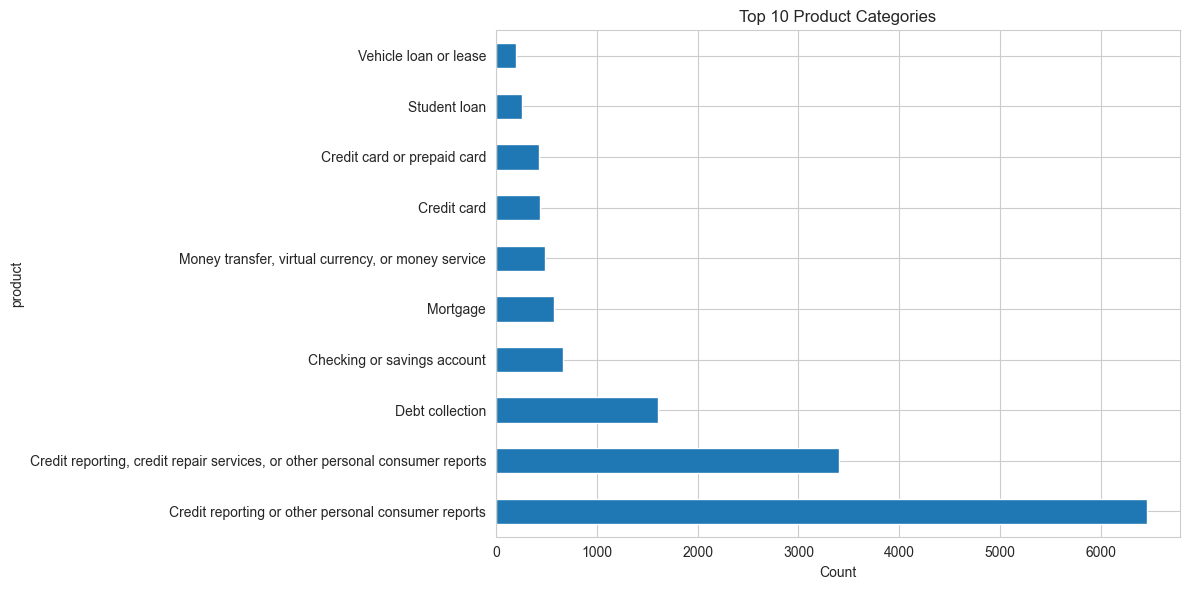

In [10]:
# Check product distribution
print("Top 10 products:")
print(df_clean['product'].value_counts().head(10))

plt.figure(figsize=(12, 6))
df_clean['product'].value_counts().head(10).plot(kind='barh')
plt.xlabel('Count')
plt.title('Top 10 Product Categories')
plt.tight_layout()
plt.show()

In [11]:
# Check issue distribution
print("Top 10 issues:")
print(df_clean['issue'].value_counts().head(10))

Top 10 issues:
issue
Incorrect information on your report                                                4764
Improper use of your report                                                         2682
Problem with a company's investigation into an existing problem                     1331
Problem with a credit reporting company's investigation into an existing problem    1039
Attempts to collect debt not owed                                                    682
Managing an account                                                                  385
Written notification about debt                                                      310
Other transaction problem                                                            216
Trouble during payment process                                                       204
Problem with a purchase shown on your statement                                      185
Name: count, dtype: int64


## Text Preprocessing

In [12]:
def clean_text(text):
    if pd.isna(text):
        return ""
    
    # Convert to string and lowercase
    text = str(text).lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text)
    
    # Remove special characters but keep basic punctuation
    text = re.sub(r'[^a-z0-9\s.,!?-]', '', text)
    
    return text.strip()

# Apply cleaning
df_clean['clean_text'] = df_clean['complaint_text'].apply(clean_text)

# Show example
print("Original:")
print(df_clean['complaint_text'].iloc[0][:300])
print("\nCleaned:")
print(df_clean['clean_text'].iloc[0][:300])

Original:
I asked to put a security free on my account a few months. I am not sure if the credit bureaus did that. I saw a handful of fraudulent accounts and credit inquires on my credit report without my knowledge.I contacted XXXX, equifax and XXXX regarding these fraudelent accounts and credit inquires and 

Cleaned:
i asked to put a security free on my account a few months. i am not sure if the credit bureaus did that. i saw a handful of fraudulent accounts and credit inquires on my credit report without my knowledge.i contacted xxxx, equifax and xxxx regarding these fraudelent accounts and credit inquires and 


Date range: 2015-03-20 00:00:00 to 2025-11-20 00:00:00


C:\Users\aswan\AppData\Local\Temp\ipykernel_2044\3191786330.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_clean.set_index('date').resample('M').size().plot()


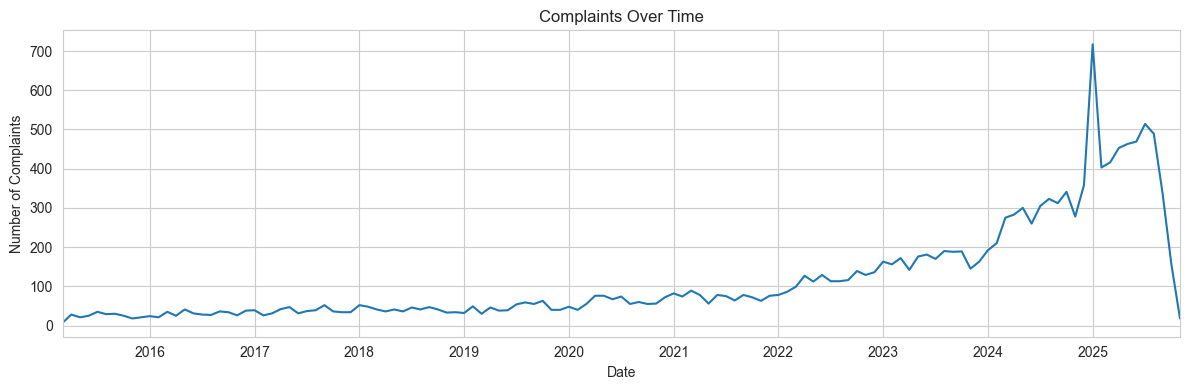

In [13]:
# Convert date to datetime
df_clean['date'] = pd.to_datetime(df_clean['date'], errors='coerce')

# Check date range
print(f"Date range: {df_clean['date'].min()} to {df_clean['date'].max()}")

# Plot complaints over time
plt.figure(figsize=(12, 4))
df_clean.set_index('date').resample('M').size().plot()
plt.xlabel('Date')
plt.ylabel('Number of Complaints')
plt.title('Complaints Over Time')
plt.tight_layout()
plt.show()

## Handle Missing Values

In [14]:
# Fill missing product and issue with 'Unknown'
df_clean['product'] = df_clean['product'].fillna('Unknown')
df_clean['issue'] = df_clean['issue'].fillna('Unknown')

# Remove rows with empty cleaned text
df_clean = df_clean[df_clean['clean_text'].str.len() > 10].copy()

print(f"Final dataset shape: {df_clean.shape}")
print(f"\nRemaining missing values:")
print(df_clean.isnull().sum())

Final dataset shape: (15000, 6)

Remaining missing values:
complaint_text    0
product           0
issue             0
date              0
text_length       0
clean_text        0
dtype: int64


## Save Processed Data

In [15]:
# Drop the temporary text_length column
df_processed = df_clean.drop('text_length', axis=1)

# Save to processed folder
output_path = '../data/processed/processed_complaints.csv'
df_processed.to_csv(output_path, index=False)
print(f"Processed data saved to: {output_path}")
print(f"Total rows: {len(df_processed)}")
print(f"Columns: {list(df_processed.columns)}")

Processed data saved to: ../data/processed/processed_complaints.csv
Total rows: 15000
Columns: ['complaint_text', 'product', 'issue', 'date', 'clean_text']


In [16]:
# Final summary
print("\n=== PREPROCESSING SUMMARY ===")
print(f"Complaints processed: {len(df_processed)}")
print(f"Unique products: {df_processed['product'].nunique()}")
print(f"Unique issues: {df_processed['issue'].nunique()}")
print(f"Date range: {df_processed['date'].min().date()} to {df_processed['date'].max().date()}")
print(f"Average complaint length: {df_processed['clean_text'].str.len().mean():.0f} characters")
df_processed.head()


=== PREPROCESSING SUMMARY ===
Complaints processed: 15000
Unique products: 20
Unique issues: 140
Date range: 2015-03-20 to 2025-11-20
Average complaint length: 995 characters


,complaint_text,product,issue,date,clean_text
2145278,I asked to put a security free on my account a few months. I am not sure if the credit bureaus d...,"Credit reporting, credit repair services, or other personal consumer reports",Incorrect information on your report,2021-03-19,i asked to put a security free on my account a few months. i am not sure if the credit bureaus d...
3893728,"On XX/XX/XXXX at XXXX XXXX, I contacted XXXX XXXX XXXX. I spoke to XXXX. XXXX identification num...",Student loan,Dealing with your lender or servicer,2018-04-21,"on xxxxxxxx at xxxx xxxx, i contacted xxxx xxxx xxxx. i spoke to xxxx. xxxx identification numbe..."
11156304,This CFPB complaint has been filed to request pursuant to FCRA 605B ( 15 U.S.C. 1681c-2 ) that y...,Credit reporting or other personal consumer reports,Improper use of your report,2025-08-19,this cfpb complaint has been filed to request pursuant to fcra 605b 15 u.s.c. 1681c-2 that you...
491315,Lakeview Loan Servicing LLC continues to contact me for payment while I am on a forbearance. The...,Mortgage,Struggling to pay mortgage,2021-04-20,lakeview loan servicing llc continues to contact me for payment while i am on a forbearance. the...
2167447,On XXXX XXXX I received my dispute results from Experian. Experian stated during their reinvesti...,"Credit reporting, credit repair services, or other personal consumer reports",Problem with a credit reporting company's investigation into an existing problem,2022-01-07,on xxxx xxxx i received my dispute results from experian. experian stated during their reinvesti...
